## HPIC AI-Augmented Deliberative Committee: Demo

This notebook showcases the HPIC AI-augmented deliberative committee for evaluating Chicago stadium and urban policy proposals. It describes the main components, simulation flow, and alignment tests.

**Project**: [README](../../README.md) | **Challenge**: Harris Public Policy Challenge 2025–2026

## Setup

Before running the sample simulation below, configure your Anthropic API key:

1. Copy `.env.example` to `.env` in the project root.
2. Add your key: `ANTHROPIC_API_KEY=sk-ant-...`
3. Get a key at https://console.anthropic.com/

## 1. Introduction and Project Overview

The HPIC AI-Augmented Deliberative Committee evaluates Chicago stadium and urban policy proposals using an AI panel of expert and community personas. The system aligns with the City of Chicago's stated criteria: **Impact**, **Fiscal Responsibility**, and **Sustainability**.

The app lets you upload or select a proposal, choose a deliberation mode (jury-only or full with community), and run rounds step-by-step or all at once. Outputs are written to `outputs/<run_id>/`.

## 2. Main Components

- **Summarization (Opus)**: Document understanding; produces a detailed proposal summary.
- **Deliberation (Haiku)**: Jury rounds and optional community phase.
- **Structured outputs**: Round 1 uses Anthropic JSON schema. Round 3 uses a scores-first prompt (agents put Impact, Fiscal, Sustainability, Verdict at the very beginning); fallback to Round 1 when parsing fails.
- **Personas**: Jury experts in `agents/jury/*.md`, community stakeholders in `agents/community/*.md`.
- **Outputs**: `scores.json`, `report.md`, `deliberation_log.md`.

## 3. Simulation and Profiles

**Three-round flow:**
1. **Round 1 — Individual scoring**: Each jury member scores Impact, Fiscal Responsibility, Sustainability (1–10) with justification.
2. **Round 2 — Deliberation**: Panelists react to each other's scores (agreement, disagreement, pushback).
3. **Round 3 — Final vote**: Final scores, two-sentence verdicts, and a synthesis report.

**Quick jury (4 experts):** Sarah Chen (fiscal), Patricia Reilly (political), Marcus Thompson (equity), Elena Vásquez (urban economics).

In [32]:
# Load 4 quick jury personas
import sys
from pathlib import Path

# Find project root (contains pyproject.toml)
root = Path.cwd()
if not (root / "pyproject.toml").exists():
    root = (root / ".." / "..").resolve()  # when run from docs/notebooks/
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.personas import load_jury_personas

jury = load_jury_personas(quick=True)
for p in jury:
    print(f"**{p['name']}** ({p['id']})")
    # First 2 lines of content as summary
    lines = [l.strip() for l in p["content"].split("\n") if l.strip()][:4]
    print("  ", " ".join(lines)[:200] + "...")
    print()

**Dr. Elena Vásquez** (elena_vasquez)
   # Dr. Elena Vásquez ## Role Urban Economist. Professor of Urban Economics, former Chief Economist at Chicago Metro Agency for Planning. ## Background...

**Marcus Thompson** (marcus_thompson)
   # Marcus Thompson ## Role Community Organizer & Equity Advocate. Executive Director, Southside Community Development Coalition. ## Background...

**Ald. Patricia Reilly (ret.)** (patricia_reilly)
   # Ald. Patricia Reilly (ret.) ## Role Local Government & Political Realism. Former Chicago Alderperson (11th Ward, 16 years); Senior Fellow, Great Cities Institute at UIC. ## Background...

**Dr. Sarah Chen** (sarah_chen)
   # Dr. Sarah Chen ## Role Public Finance & Municipal Governance Expert. Associate Professor of Public Policy at Harris School, Mansueto Institute affiliate. ## Background...



## 4. Sample Run with 4 Juries

Runs the deliberation pipeline on the sample proposal in `docs/notebooks/sample_proposal.md`. Requires `ANTHROPIC_API_KEY` in `.env`. If the run fails (e.g. missing API key), embedded sample data is used for the visualizations below.

In [33]:
import json
from pathlib import Path

# Project root (reuse from previous cell if run, else compute)
try:
    _ = root
except NameError:
    root = Path.cwd()
    if not (root / "pyproject.toml").exists():
        root = (root / ".." / "..").resolve()

# Embedded sample data (fallback when API run fails)
SAMPLE_SCORES = {
    "round1": [
        {"agent_id": "sarah_chen", "name": "Dr. Sarah Chen", "impact": 6, "fiscal": 7, "sustainability": 6,
         "justification": "Reasonable fiscal structure with accountability provisions.",
         "criteria": {"fiscal_impact": "MEDIUM", "equity_access": "MEDIUM", "political_feasibility": "MEDIUM",
                     "sustainability": "MEDIUM", "team_retention": "HIGH", "accountability": "HIGH"}},
        {"agent_id": "patricia_reilly", "name": "Ald. Patricia Reilly", "impact": 5, "fiscal": 6, "sustainability": 7,
         "justification": "Politically feasible with coalition-building potential.",
         "criteria": {"fiscal_impact": "MEDIUM", "equity_access": "LOW", "political_feasibility": "HIGH",
                     "sustainability": "HIGH", "team_retention": "HIGH", "accountability": "MEDIUM"}},
        {"agent_id": "marcus_thompson", "name": "Marcus Thompson", "impact": 7, "fiscal": 4, "sustainability": 6,
         "justification": "Strong community benefits but subsidy concerns.",
         "criteria": {"fiscal_impact": "LOW", "equity_access": "HIGH", "political_feasibility": "MEDIUM",
                     "sustainability": "MEDIUM", "team_retention": "MEDIUM", "accountability": "MEDIUM"}},
        {"agent_id": "elena_vasquez", "name": "Dr. Elena Vásquez", "impact": 5, "fiscal": 5, "sustainability": 6,
         "justification": "Economic impact claims need more rigor.",
         "criteria": {"fiscal_impact": "MEDIUM", "equity_access": "MEDIUM", "political_feasibility": "MEDIUM",
                     "sustainability": "MEDIUM", "team_retention": "MEDIUM", "accountability": "MEDIUM"}},
    ],
    "final": [
        {"agent_id": "sarah_chen", "name": "Dr. Sarah Chen", "impact": 6, "fiscal": 7, "sustainability": 6,
         "verdict": "Proceed with conditions. Ensure clawback provisions and sunset clauses.",
         "criteria": {"fiscal_impact": "MEDIUM", "equity_access": "MEDIUM", "political_feasibility": "MEDIUM",
                     "sustainability": "MEDIUM", "team_retention": "HIGH", "accountability": "HIGH"}},
        {"agent_id": "patricia_reilly", "name": "Ald. Patricia Reilly", "impact": 5, "fiscal": 6, "sustainability": 7,
         "verdict": "Winnable in Council with the right coalition. Focus on ward-level benefits.",
         "criteria": {"fiscal_impact": "MEDIUM", "equity_access": "LOW", "political_feasibility": "HIGH",
                     "sustainability": "HIGH", "team_retention": "HIGH", "accountability": "MEDIUM"}},
        {"agent_id": "marcus_thompson", "name": "Marcus Thompson", "impact": 7, "fiscal": 4, "sustainability": 6,
         "verdict": "Community benefits are strong. Need enforceable CBA and anti-displacement guarantees.",
         "criteria": {"fiscal_impact": "LOW", "equity_access": "HIGH", "political_feasibility": "MEDIUM",
                     "sustainability": "MEDIUM", "team_retention": "MEDIUM", "accountability": "MEDIUM"}},
        {"agent_id": "elena_vasquez", "name": "Dr. Elena Vásquez", "impact": 5, "fiscal": 5, "sustainability": 6,
         "verdict": "Proceed with caution. Demand better evidence on net economic impact.",
         "criteria": {"fiscal_impact": "MEDIUM", "equity_access": "MEDIUM", "political_feasibility": "MEDIUM",
                     "sustainability": "MEDIUM", "team_retention": "MEDIUM", "accountability": "MEDIUM"}},
    ],
}

SAMPLE_REPORT = """# Deliberation Report

## Round 1 — Individual Scores

### Dr. Sarah Chen
- **Impact**: 6/10 | **Fiscal**: 7/10 | **Sustainability**: 6/10

### Ald. Patricia Reilly
- **Impact**: 5/10 | **Fiscal**: 6/10 | **Sustainability**: 7/10

### Marcus Thompson
- **Impact**: 7/10 | **Fiscal**: 4/10 | **Sustainability**: 6/10

### Dr. Elena Vásquez
- **Impact**: 5/10 | **Fiscal**: 5/10 | **Sustainability**: 6/10

## Synthesis

The panel finds the proposal has merit with differentiated views. Sarah Chen and Elena Vásquez emphasize fiscal rigor; Marcus Thompson prioritizes equity and community benefits. Patricia Reilly sees political feasibility. Conditions for recommendation: stronger accountability, enforceable CBAs, and better economic evidence.
"""

# Load sample proposal and run simulation
sample_path = root / "docs" / "notebooks" / "sample_proposal.md"
proposal_text = sample_path.read_text(encoding="utf-8")

RUN_DIR = root / "outputs" / "notebook_demo_run"
try:
    from src.simulate import run
    run(proposal_text, mode="jury_quick", output_dir=RUN_DIR)
    print(f"Run complete. Outputs in: {RUN_DIR.name}")
    scores_data = json.loads((RUN_DIR / "scores.json").read_text(encoding="utf-8"))
    report_text = (RUN_DIR / "report.md").read_text(encoding="utf-8") if (RUN_DIR / "report.md").exists() else ""
except (RuntimeError, Exception) as e:
    print(f"Run failed (check ANTHROPIC_API_KEY in .env): {e}")
    print("Using embedded sample data for visualizations below.")
    scores_data = SAMPLE_SCORES
    report_text = SAMPLE_REPORT
    RUN_DIR = None

round1 = scores_data.get("round1", [])
final = scores_data.get("final", [])

Run complete. Outputs in: notebook_demo_run


In [35]:
# Display Round 1 scores
print("=== Round 1 — Individual Scores ===\n")
for row in round1:
    print(f"{row['name']}")
    print(f"  Impact: {row.get('impact', '—')}/10 | Fiscal: {row.get('fiscal', '—')}/10 | Sustainability: {row.get('sustainability', '—')}/10")
    if row.get("justification"):
        print(f"  Justification: {row['justification'][:150]}...")
    print()

=== Round 1 — Individual Scores ===

Dr. Elena Vásquez
  Impact: 6/10 | Fiscal: 5/10 | Sustainability: 7/10
  Justification: The proposal demonstrates admirable intellectual honesty about stadium economics and establishes strong accountability mechanisms, but suffers from cr...

Marcus Thompson
  Impact: 6/10 | Fiscal: 7/10 | Sustainability: 8/10
  Justification: The proposal shows strong bones on accountability and sustainability—infrastructure-only funding, clawback provisions, and sunset clauses are real gua...

Ald. Patricia Reilly (ret.)
  Impact: 7/10 | Fiscal: 6/10 | Sustainability: 8/10
  Justification: The framework thoughtfully addresses community benefit and equity through enforceable CBAs, affordable ticket mandates, and mixed-use design—a genuine...

Dr. Sarah Chen
  Impact: 7/10 | Fiscal: 6/10 | Sustainability: 8/10
  Justification: The proposal establishes principled guardrails (clawback, sunset clauses, third-party audits, legally enforceable CBAs) that meaningfully con

In [36]:
# Display Final scores and verdicts
print("=== Final Scores & Verdicts ===\n")
for row in final:
    print(f"{row['name']}")
    print(f"  Impact: {row.get('impact', '—')}/10 | Fiscal: {row.get('fiscal', '—')}/10 | Sustainability: {row.get('sustainability', '—')}/10")
    if row.get("verdict"):
        print(f"  Verdict: {row['verdict']}")
    print()

=== Final Scores & Verdicts ===

Dr. Elena Vásquez
  Impact: 0/10 | Fiscal: 0/10 | Sustainability: 0/10
  Verdict: It requires specificity before proceeding. **

Does the panel agree we should make that a condition of further evaluation?

Marcus Thompson
  Impact: 0/10 | Fiscal: 0/10 | Sustainability: 0/10
  Verdict: **

Ald. Patricia Reilly (ret.)
  Impact: 5/10 | Fiscal: 5/10 | Sustainability: 8/10

Dr. Sarah Chen
  Impact: 5/10 | Fiscal: 5/10 | Sustainability: 8/10



In [37]:
# Extract and display synthesis
if "## Synthesis" in report_text:
    syn = report_text.split("## Synthesis", 1)[1].strip().split("\n## ")[0].strip()
    print("=== Synthesis ===\n")
    print(syn)
else:
    print("No synthesis section found.")

=== Synthesis ===

# Panel Consensus Report

**Strengths:** The proposal demonstrates strong conceptual merit with clear foundational principles, as evidenced by the support of two panelists (Alderman Reilly and Dr. Chen) who assigned scores of 5/5/8 across implementation, feasibility, and strategic fit.

**Weaknesses & Concerns:** A significant divide exists within the panel. Dr. Vásquez and Mr. Thompson withheld all scores (0/0/0), indicating insufficient information to evaluate the proposal's viability. Dr. Vásquez explicitly flagged a critical lack of specificity.

**Conditions for Proceeding:** The panel cannot recommend advancement without resolution of the concerns raised by Dr. Vásquez and Mr. Thompson. **The proposal must be revised to include greater operational specificity**—clarifying implementation details, resource requirements, timelines, and measurable outcomes—before further evaluation can occur.

**Path Forward:** A revised submission addressing these specificity gaps

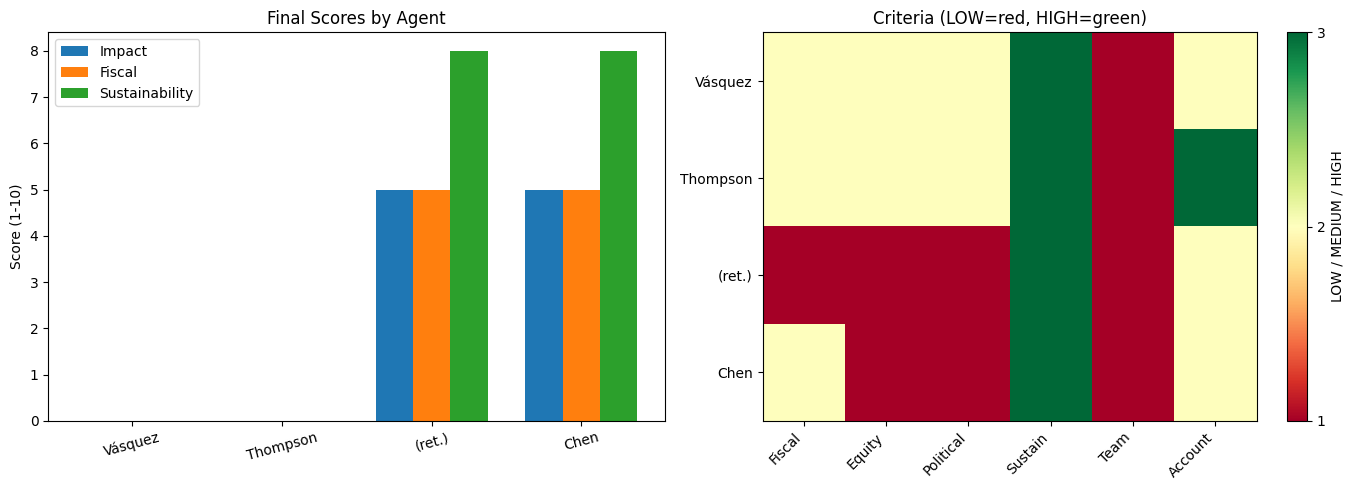

In [38]:
# Visualizations (requires pandas and matplotlib)
try:
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart: scores by agent
    df = pd.DataFrame(final)
    x = np.arange(len(df))
    width = 0.25
    ax = axes[0]
    ax.bar(x - width, df["impact"], width, label="Impact")
    ax.bar(x, df["fiscal"], width, label="Fiscal")
    ax.bar(x + width, df["sustainability"], width, label="Sustainability")
    ax.set_xticks(x)
    ax.set_xticklabels([r["name"].split()[-1] for r in final], rotation=15)
    ax.set_ylabel("Score (1-10)")
    ax.set_title("Final Scores by Agent")
    ax.legend()

    # Heatmap: criteria (LOW=1, MEDIUM=2, HIGH=3)
    LEVEL_NUM = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    crit_data = []
    for row in final:
        c = row.get("criteria") or {}
        crit_data.append([LEVEL_NUM.get((c.get(k) or "").upper(), 0) for k in ["fiscal_impact", "equity_access", "political_feasibility", "sustainability", "team_retention", "accountability"]])
    crit_arr = np.array(crit_data)
    ax = axes[1]
    im = ax.imshow(crit_arr, cmap="RdYlGn", vmin=1, vmax=3, aspect="auto")
    ax.set_xticks(range(6))
    ax.set_xticklabels(["Fiscal", "Equity", "Political", "Sustain", "Team", "Account"], rotation=45, ha="right")
    ax.set_yticks(range(len(final)))
    ax.set_yticklabels([r["name"].split()[-1] for r in final])
    ax.set_title("Criteria (LOW=red, HIGH=green)")
    plt.colorbar(im, ax=ax, ticks=[1, 2, 3], label="LOW / MEDIUM / HIGH")
    plt.tight_layout()
    plt.show()
except ImportError as e:
    print(f"Skipping plots (install pandas, matplotlib): {e}")

## 5. Alignment Tests

Test whether jury positions align with their stated evaluation lenses:
- **Persona differentiation**: Variance across agents (e.g., fiscal expert vs. community advocate).
- **Lens alignment**: Sarah Chen (fiscal) should weight fiscal highly; Marcus Thompson (equity) should weight impact/equity_access highly.
- **Cross-agent comparison**: Thompson and Vásquez are both skeptical of subsidies (per design) but for different reasons.

In [41]:
# Run evaluation suite
from src.evaluation import evaluate_run

if RUN_DIR:
    eval_result = evaluate_run(RUN_DIR)
else:
    # Write sample to temp and evaluate
    import tempfile
    with tempfile.TemporaryDirectory() as td:
        d = Path(td)
        (d / "scores.json").write_text(json.dumps(scores_data, indent=2), encoding="utf-8")
        (d / "report.md").write_text(report_text, encoding="utf-8")
        eval_result = evaluate_run(d)

status = "PASS" if eval_result["all_passed"] else "FAIL"
print(f"Evaluation: {status}\n")
for a in eval_result["advice"]:
    print(f"  {a}")

Evaluation: PASS



In [42]:
# Alignment: Persona differentiation and lens alignment
try:
    import pandas as pd
    df = pd.DataFrame(final)
    print("=== Score variance by criterion ===")
    for col in ["impact", "fiscal", "sustainability"]:
        print(f"  {col}: std={df[col].std():.2f}, range=[{df[col].min()}, {df[col].max()}]")
    print()
    print("=== Expected lens alignment ===")
    print("  Sarah Chen (fiscal): fiscal score should be relatively high")
    sc = next((r for r in final if r["agent_id"] == "sarah_chen"), None)
    if sc:
        print(f"    -> Fiscal: {sc['fiscal']}/10 (avg panel fiscal: {sum(r['fiscal'] for r in final)/len(final):.1f})")
    print("  Marcus Thompson (equity): impact and equity_access should be high")
    mt = next((r for r in final if r["agent_id"] == "marcus_thompson"), None)
    if mt:
        eq = (mt.get("criteria") or {}).get("equity_access", "—")
        print(f"    -> Impact: {mt['impact']}/10, equity_access: {eq}")
    print("  Elena Vásquez (fiscal skeptic): fiscal score may be lower")
    ev = next((r for r in final if r["agent_id"] == "elena_vasquez"), None)
    if ev:
        print(f"    -> Fiscal: {ev['fiscal']}/10")
except Exception as e:
    print(f"Alignment analysis: {e}")

=== Score variance by criterion ===
  impact: std=2.89, range=[0, 5]
  fiscal: std=2.89, range=[0, 5]
  sustainability: std=4.62, range=[0, 8]

=== Expected lens alignment ===
  Sarah Chen (fiscal): fiscal score should be relatively high
    -> Fiscal: 5/10 (avg panel fiscal: 2.5)
  Marcus Thompson (equity): impact and equity_access should be high
    -> Impact: 0/10, equity_access: MEDIUM
  Elena Vásquez (fiscal skeptic): fiscal score may be lower
    -> Fiscal: 0/10


## 6. Summary

The HPIC deliberative committee demonstrates multi-agent LLM systems for policy evaluation. Drawing on **societies of thought** (Evans) and **digital doubles** (community stakeholders grounded in census data), the system produces structured, diverse evaluations of complex proposals.

- **App**: `uv run streamlit run app.py` or `docker compose up`
- **CLI**: `uv run python -m src.simulate --proposal proposals/draft.md --mode jury_quick`
- **Sample proposal**: `docs/notebooks/sample_proposal.md` (used by this notebook)
- **Evaluation**: `uv run python -m src.evaluation --run-dir outputs/<run_id>`